In [3]:
from google.colab import drive

drive.mount('/content/drive')
import pandas as pd
df=pd.read_csv('/content/heart (1).csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
df.dropna(inplace=True)
from sklearn.preprocessing import LabelEncoder
label_encoders={}
for col in df.select_dtypes(include=['object']).columns:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])
  label_encoders[col]=le

In [8]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['target'])
y=df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svm_linear=SVC(kernel='linear',C=1)
svm_linear.fit(X_train,y_train)
y_pred_linear=svm_linear.predict(X_test)
accuracy_linear=accuracy_score(y_test,y_pred_linear)
print("Accuracy with Linear Kernel:",accuracy_linear)

Accuracy with Linear Kernel: 0.8146341463414634


In [23]:
svm_poly=SVC(kernel='poly',degree=3,C=1)
svm_poly.fit(X_train,y_train)
y_pred_poly=svm_poly.predict(X_test)
accuracy_poly=accuracy_score(y_test,y_pred_poly)
print("Accuracy with Linear Kernel:",accuracy_poly)

Accuracy with Linear Kernel: 0.9073170731707317


In [24]:
from sklearn.metrics import confusion_matrix
cm_linear=confusion_matrix(y_test,y_pred_linear)
cm_poly=confusion_matrix(y_test,y_pred_poly)
print("Confusion Matrix with Linear Kernel:")
print(cm_linear)
print("\nConfusion Matrix with Polynomial Kernel:")
print(cm_poly)

Confusion Matrix with Linear Kernel:
[[72 30]
 [ 8 95]]

Confusion Matrix with Polynomial Kernel:
[[ 85  17]
 [  2 101]]


In [26]:
svm_rbf=SVC(kernel='rbf',gamma='auto',C=1)
svm_rbf.fit(X_train,y_train)
y_pred_rbf=svm_rbf.predict(X_test)
accuracy_rbf=accuracy_score(y_test,y_pred_rbf)
print("Accuracy with RBF Kernel:",accuracy_rbf)
cm_rbf=confusion_matrix(y_test,y_pred_rbf)
print("\nConfusion Matrix with RBF Kernel:")
print(cm_rbf)

Accuracy with RBF Kernel: 0.8878048780487805

Confusion Matrix with RBF Kernel:
[[85 17]
 [ 6 97]]


In [57]:
df=pd.read_csv('/content/train_u6lujuX_CVtuZ9i[1].csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [59]:
import pandas as pd

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


Numerical Columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


/tmp/ipython-input-2865836079.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipython-input-2865836079.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [60]:
df.isnull().sum()


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [61]:
cols_to_drop = ['Loan_ID', 'Gender', 'Dependents']
df = df.drop(columns=cols_to_drop)


In [65]:
df.columns


Index(['Married', 'Education', 'Self_Employed', 'ApplicantIncome',
       'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [67]:
y = df['Loan_Status']          # contains 'Yes' / 'No'
X = df.drop('Loan_Status', axis=1)

In [68]:
print(X.columns)


Index(['Married', 'Education', 'Self_Employed', 'ApplicantIncome',
       'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History',
       'Property_Area'],
      dtype='object')


In [70]:
X = pd.get_dummies(X, drop_first=True)


In [71]:
X.dtypes


,0
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64
Married_Yes,bool
Education_Not Graduate,bool
Self_Employed_Yes,bool
Property_Area_Semiurban,bool
Property_Area_Urban,bool


In [72]:
X.select_dtypes(include='object').columns


Index([], dtype='object')

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [75]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', C=1, random_state=42)
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)


In [76]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))
print("\nClassification Report:\n", classification_report(y_test, y_pred_linear))


Linear SVM Accuracy: 0.8536585365853658

Confusion Matrix:
 [[21 17]
 [ 1 84]]

Classification Report:
               precision    recall  f1-score   support

           N       0.95      0.55      0.70        38
           Y       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [77]:
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)


In [78]:
print("RBF SVM Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rbf))


RBF SVM Accuracy: 0.8373983739837398

Confusion Matrix:
 [[21 17]
 [ 3 82]]

Classification Report:
               precision    recall  f1-score   support

           N       0.88      0.55      0.68        38
           Y       0.83      0.96      0.89        85

    accuracy                           0.84       123
   macro avg       0.85      0.76      0.78       123
weighted avg       0.84      0.84      0.83       123



In [83]:
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)


In [84]:
print("RBF SVM Accuracy:", accuracy_score(y_test, y_pred_poly))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_poly))
print("\nClassification Report:\n", classification_report(y_test, y_pred_poly))


RBF SVM Accuracy: 0.8536585365853658

Confusion Matrix:
 [[22 16]
 [ 2 83]]

Classification Report:
               precision    recall  f1-score   support

           N       0.92      0.58      0.71        38
           Y       0.84      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.88      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [111]:
df['Loan_Status'].isnull().sum()


np.int64(0)

In [112]:
# Ensure Loan_Status has no missing values
df['Loan_Status'] = df['Loan_Status'].fillna(df['Loan_Status'].mode()[0])


In [114]:
df['Loan_Status'].unique()


array(['Y', 'N'], dtype=object)

In [115]:
# Encode target correctly
y = df['Loan_Status'].replace({'Y': 1, 'N': 0}).astype(int)


/tmp/ipython-input-2952468321.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df['Loan_Status'].replace({'Y': 1, 'N': 0}).astype(int)


In [116]:
print("NaNs in y:", y.isnull().sum())
print("Unique values in y:", y.unique())


NaNs in y: 0
Unique values in y: [1 0]


In [117]:
# Features
X = df.drop('Loan_Status', axis=1)
X = pd.get_dummies(X, drop_first=True)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [118]:
def plot_svm(kernel, title, degree=3):
    if kernel == 'poly':
        model = SVC(kernel=kernel, degree=degree, C=1)
    else:
        model = SVC(kernel=kernel, C=1)

    model.fit(X_pca, y)

    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(title)
    plt.show()


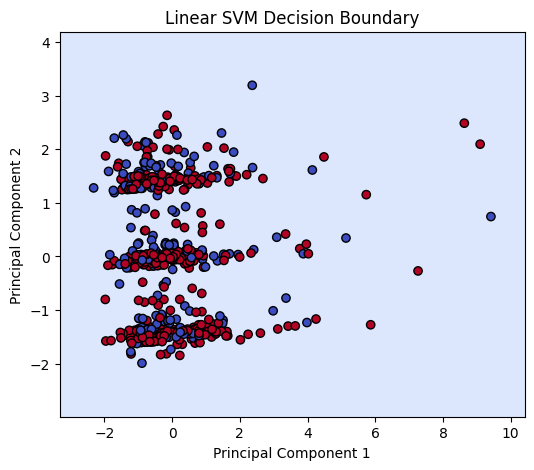

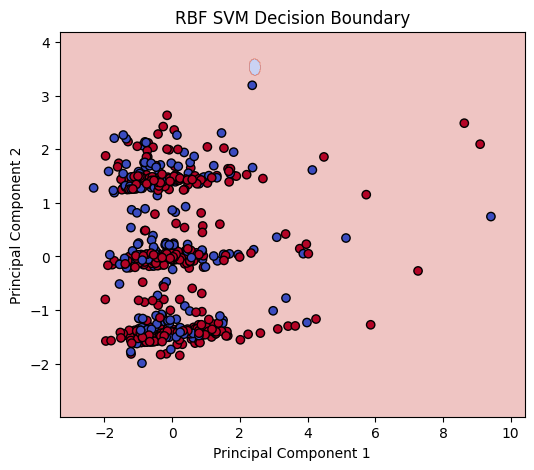

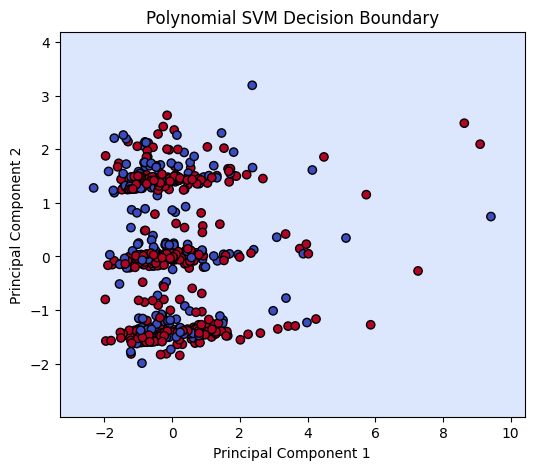

In [119]:
plot_svm(kernel='linear', title='Linear SVM Decision Boundary')
plot_svm(kernel='rbf', title='RBF SVM Decision Boundary')
plot_svm(kernel='poly', degree=3, title='Polynomial SVM Decision Boundary')
